## 探索性数据分析 (EDA) - 时间滞后特征分析

#### 本notebook对LCL电力数据集进行统计数据分析，不仅基于原始数据，还基于10个观测值的时间窗口来生成滞后特征，用于时间序列预测

In [1]:
import os

import sys

from pathlib import Path


parent = Path(os.path.abspath("")).resolve().parents[0]

if parent not in sys.path:
    sys.path.insert(0, str(parent))

In [2]:
import copy

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as ticker
import seaborn as sns
import colorcet as cc

import warnings
warnings.filterwarnings("ignore")

In [3]:
from ml.utils.data_utils import read_data, generate_time_lags

### 读取LCL电力数据集

In [8]:
# 加载LCL电力数据集
data_path = "../CBL-dataset/LCL-June2015v2_0.csv"
print(f"正在加载数据集: {data_path}")

# 读取CSV文件
df = pd.read_csv(data_path)

# 清理列名（去除空格）
df.columns = df.columns.str.strip()

# 重命名列以便于使用
df = df.rename(columns={
    'LCLid': 'customer_id',
    'stdorToU': 'tariff_type',
    'DateTime': 'datetime',
    'KWH/hh (per half hour)': 'kwh'
})

# 转换数据类型
df['datetime'] = pd.to_datetime(df['datetime'], format="%Y-%m-%d %H:%M:%S.%f", errors='coerce')
df['kwh'] = pd.to_numeric(df['kwh'], errors='coerce')

# 删除tariff_type列（电价类型全是'Std'，且是字符串类型，不适合创建滞后特征）
df = df.drop(['tariff_type'], axis=1)
print(f"已删除tariff_type列（电价类型全为标准模式'Std'）")

# 设置时间索引（与read_data函数格式一致）
df.set_index(pd.DatetimeIndex(df["datetime"]), inplace=True)
df.drop(["datetime"], axis=1, inplace=True)

# 确保只保留customer_id和kwh列
df = df[['customer_id', 'kwh']].copy()

# 将kwh转换为float32
df['kwh'] = df['kwh'].astype("float32")

print(f"\n数据集形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")
print(f"唯一客户数: {df['customer_id'].nunique()}")
print(f"时间范围: {df.index.min()} 到 {df.index.max()}")
print(f"\n确认tariff_type列已删除: {'tariff_type' not in df.columns}")

正在加载数据集: ../CBL-dataset/LCL-June2015v2_0.csv
已删除tariff_type列（电价类型全为标准模式'Std'）

数据集形状: (1000000, 2)
列名: ['customer_id', 'kwh']
唯一客户数: 30
时间范围: 2011-12-06 13:00:00 到 2014-02-28 00:00:00

确认tariff_type列已删除: True


In [9]:
# 查看各客户的数据量
customer_counts = df['customer_id'].value_counts()
print("各客户的数据点数量:")
print(customer_counts.head(10))
print(f"\n总客户数: {len(customer_counts)}")
print(f"平均每个客户的数据点数: {customer_counts.mean():.0f}")

各客户的数据点数量:
customer_id
MAC000018    39082
MAC000020    39079
MAC000021    39079
MAC000022    39072
MAC000033    39071
MAC000019    39071
MAC000034    39070
MAC000023    39069
MAC000032    39069
MAC000027    39069
Name: count, dtype: int64

总客户数: 30
平均每个客户的数据点数: 33333


In [10]:
df

,customer_id,kwh
datetime,,
2012-10-12 00:30:00,MAC000002,0.000
2012-10-12 01:00:00,MAC000002,0.000
2012-10-12 01:30:00,MAC000002,0.000
2012-10-12 02:00:00,MAC000002,0.000
2012-10-12 02:30:00,MAC000002,0.000
...,...,...
2012-11-08 08:00:00,MAC000036,0.228
2012-11-08 08:30:00,MAC000036,0.042
2012-11-08 09:00:00,MAC000036,0.076


### 生成包含10个观测值的时间滞后特征，用于预测

In [11]:
# 生成滞后特征（X特征）
# 注意：需要将customer_id作为identifier参数传入
df_lags_X = generate_time_lags(df, 10, identifier="customer_id")
print(f"滞后特征数据集形状: {df_lags_X.shape}")
print(f"滞后特征列数: {len(df_lags_X.columns)}")

滞后特征数据集形状: (999700, 11)
滞后特征列数: 11


In [12]:
df_lags_X.head()

,kwh_lag-10,kwh_lag-9,kwh_lag-8,kwh_lag-7,kwh_lag-6,kwh_lag-5,kwh_lag-4,kwh_lag-3,kwh_lag-2,kwh_lag-1,customer_id
datetime,,,,,,,,,,,
2012-10-12 05:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAC000002
2012-10-12 06:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAC000002
2012-10-12 06:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAC000002
2012-10-12 07:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAC000002
2012-10-12 07:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MAC000002


In [13]:
# 生成目标值（y）
df_lags_y = generate_time_lags(df, 10, identifier="customer_id", is_y=True)
print(f"目标数据集形状: {df_lags_y.shape}")
print(f"目标数据集列名: {df_lags_y.columns.tolist()}")

目标数据集形状: (999700, 2)
目标数据集列名: ['customer_id', 'kwh']


In [14]:
df_lags_y.head()

,customer_id,kwh
datetime,,
2012-10-12 05:30:00,MAC000002,0.0
2012-10-12 06:00:00,MAC000002,0.0
2012-10-12 06:30:00,MAC000002,0.0
2012-10-12 07:00:00,MAC000002,0.0
2012-10-12 07:30:00,MAC000002,0.0


In [15]:
len(df_lags_X), len(df_lags_y)

(999700, 999700)

### 绘制散点图：分析时间滞后特征与目标值的关系（按客户分组）

In [16]:
def scatter_plot(df, x_axis, y_axis, customer_id):
    fig, ax = plt.subplots(figsize=(10,6))
    ax.ticklabel_format(style='plain')

    sns.scatterplot(x=df[x_axis], y=df[y_axis], alpha=0.5)

    ax.set_title(f'客户 {customer_id}: {x_axis} vs {y_axis}', fontsize = 15, loc='center')
    ax.set_ylabel(y_axis, fontsize = 13)
    ax.set_xlabel(x_axis, fontsize = 13)
    plt.tick_params(axis='x', which='major', labelsize=12)
    plt.tick_params(axis='y', which='major', labelsize=10)
    ax.yaxis.tick_left()
    plt.tight_layout()
    plt.show()
    plt.close()

选择前5个数据量最多的客户进行可视化: ['MAC000018', 'MAC000020', 'MAC000021', 'MAC000022', 'MAC000033']



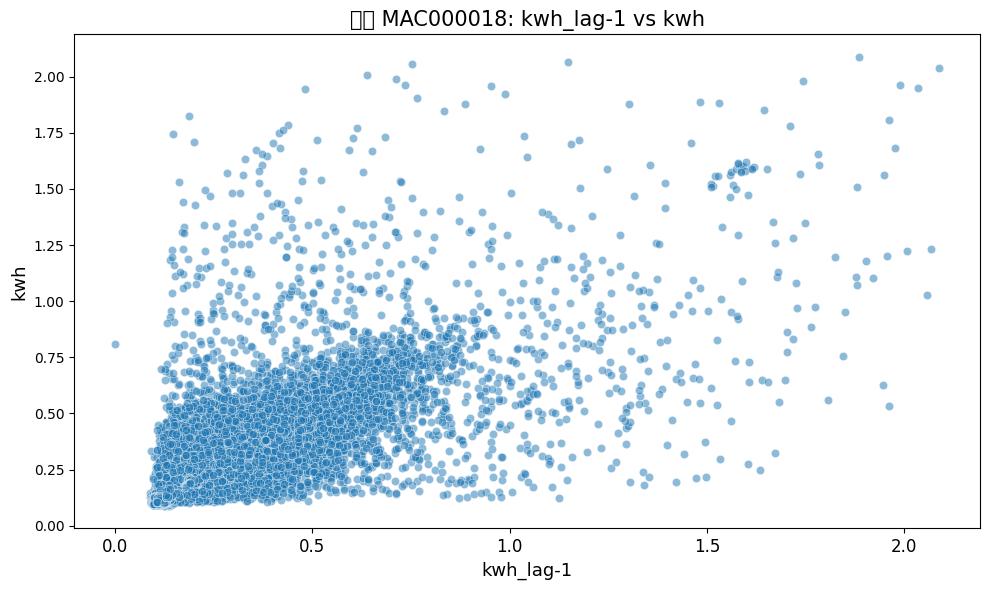

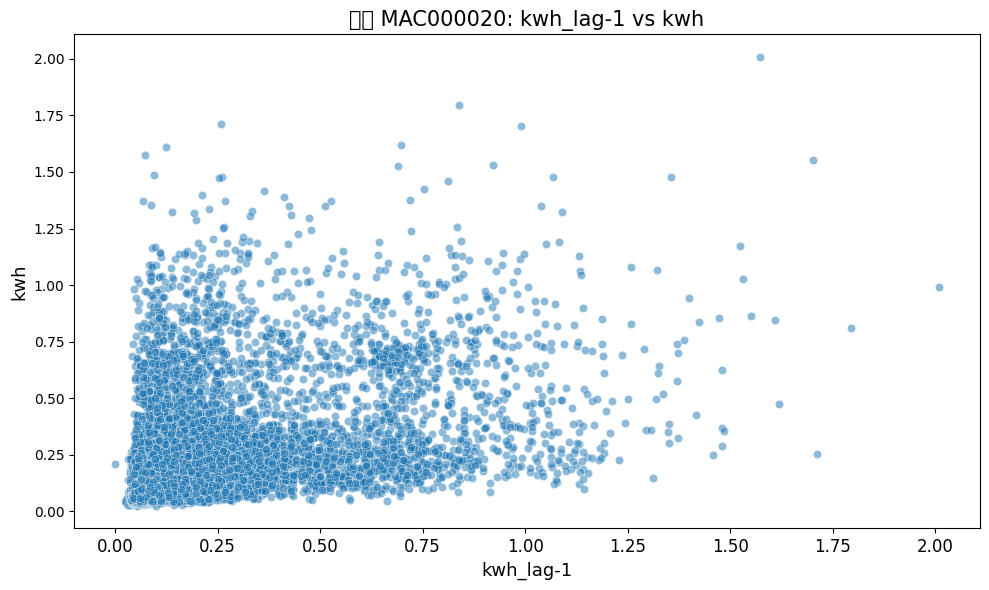

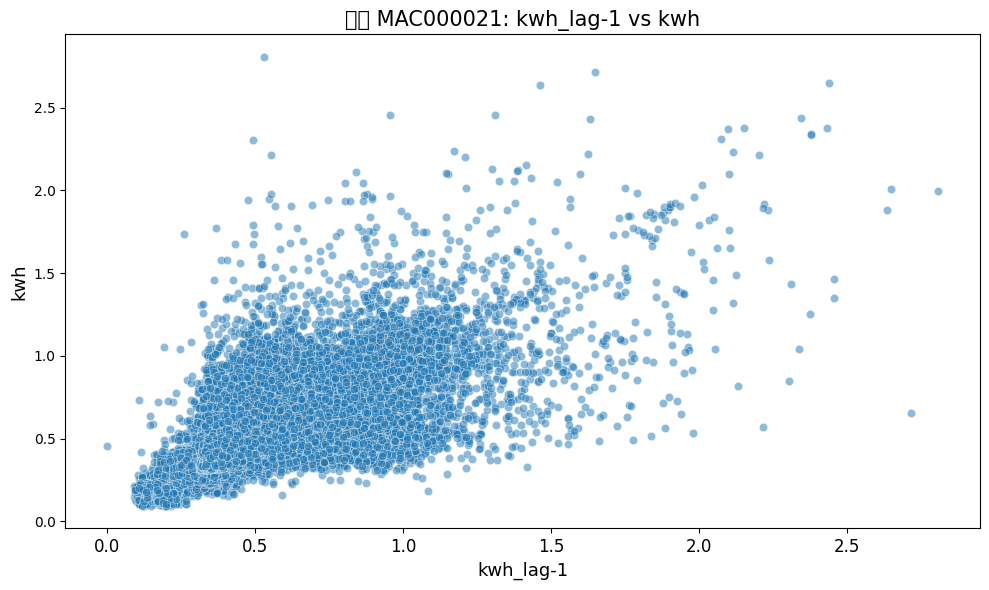

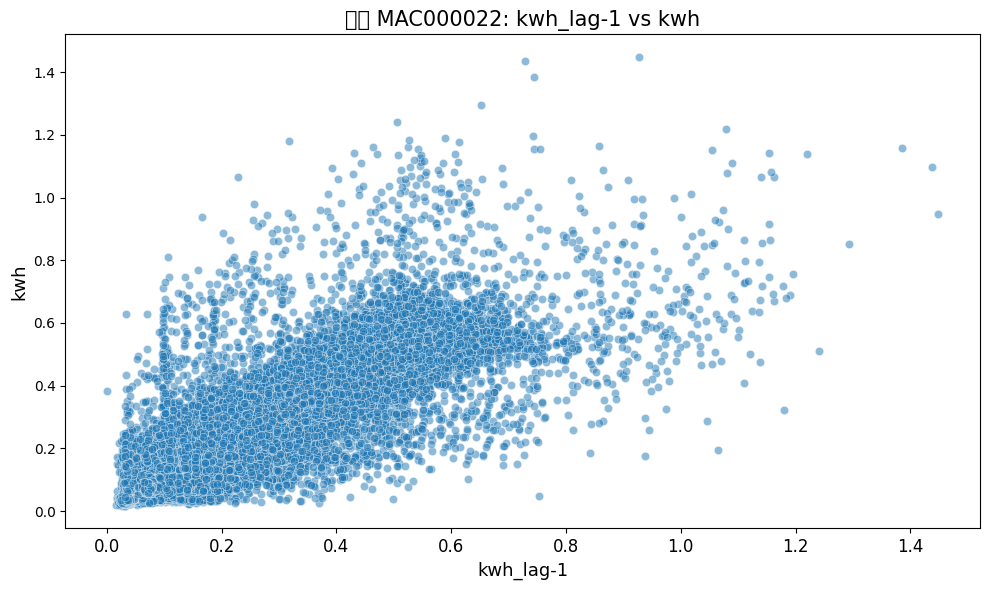

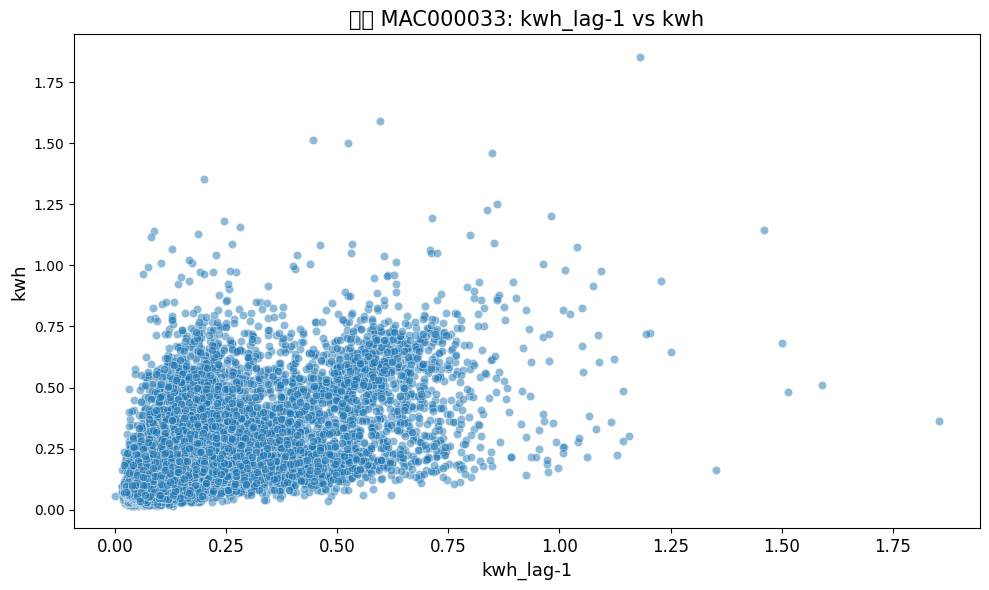

In [17]:
# 选择几个代表性客户进行可视化（数据量最多的前5个客户）
top_customers = df_lags_y['customer_id'].value_counts().head(5).index.tolist()
print(f"选择前5个数据量最多的客户进行可视化: {top_customers}\n")

# 绘制kwh与lag-1的关系（当前值与前一个时间步的关系）
for customer_id in top_customers:
    tmp_y = df_lags_y.loc[df_lags_y.customer_id == customer_id]
    tmp_X = df_lags_X.loc[df_lags_X.customer_id == customer_id]
    
    if len(tmp_y) > 0 and len(tmp_X) > 0 and 'kwh_lag-1' in tmp_X.columns:
        # 对齐索引（df_lags_X和df_lags_y应该有相同的索引）
        common_idx = tmp_y.index.intersection(tmp_X.index)
        if len(common_idx) > 100:  # 至少需要100个数据点
            scatter_data = pd.DataFrame({
                'kwh_lag-1': tmp_X.loc[common_idx, 'kwh_lag-1'].values,
                'kwh': tmp_y.loc[common_idx, 'kwh'].values
            })
            scatter_plot(scatter_data, "kwh_lag-1", "kwh", customer_id)
        else:
            print(f"客户 {customer_id} 的数据点不足，跳过散点图")

### 绘制每个客户的用电量分布图

In [18]:
def sci_format(x, lim):
    return '{:.1e}'.format(x)

def distribution_plot(df, x_axis, customer_id, bins=None):
    fig, ax = plt.subplots(figsize=(10,6))
    
    sns.histplot(df[x_axis], kde=True, 
                 bins=bins, alpha=.4, edgecolor=(1, 1, 1, .4),
                 stat="count", kde_kws=dict(cut=3),
                )

    ax.set_xlabel("用电量 (KWH)", fontsize=12)
    ax.set_ylabel("频数", fontsize=12)
    ax.set_title(f'客户 {customer_id} 的用电量分布', fontsize=14, fontweight='bold')
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.yaxis.tick_left() 
    plt.tight_layout()
    plt.show()
    plt.close()

绘制前5个客户的用电量分布图


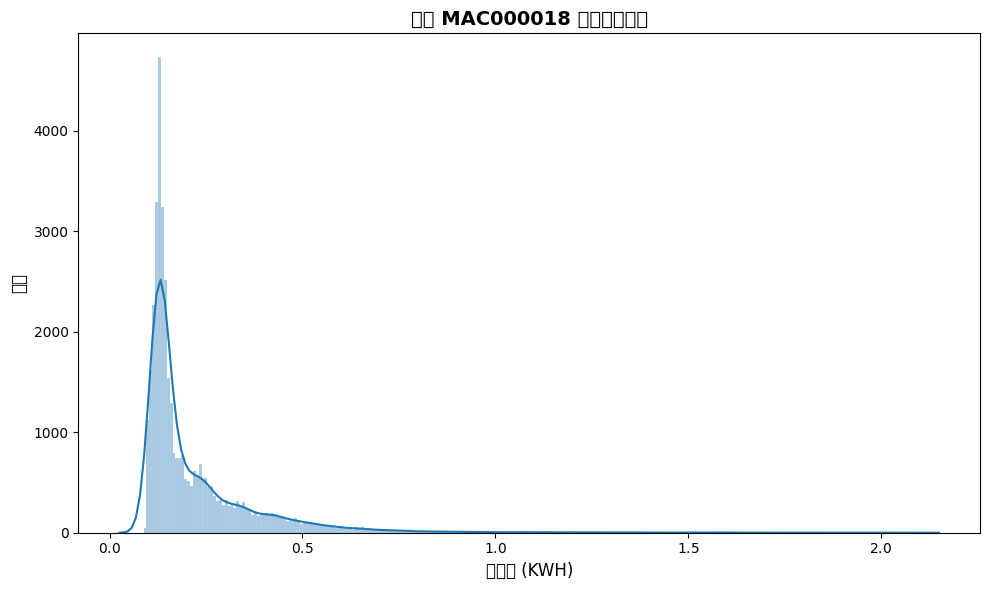

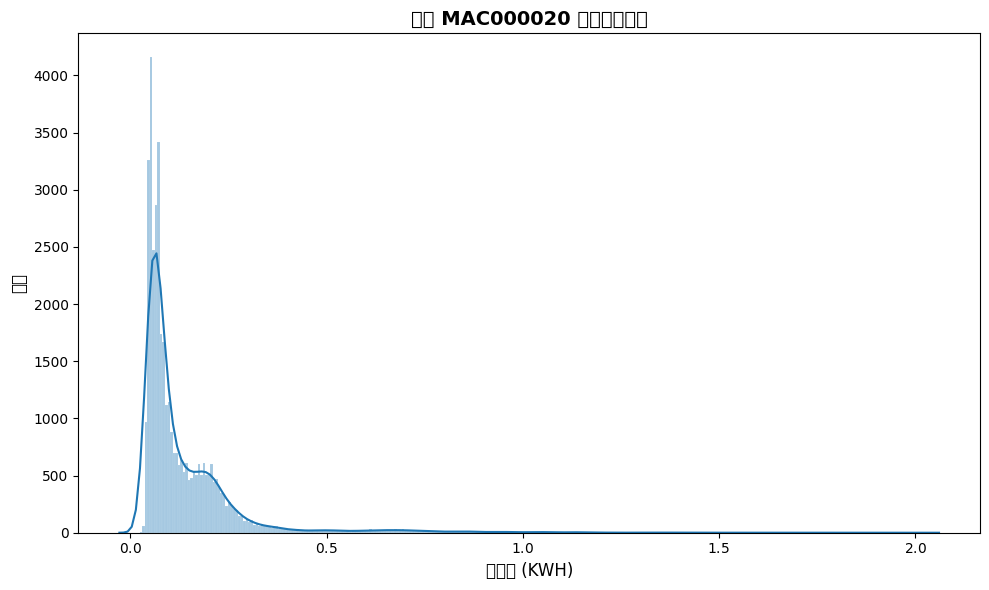

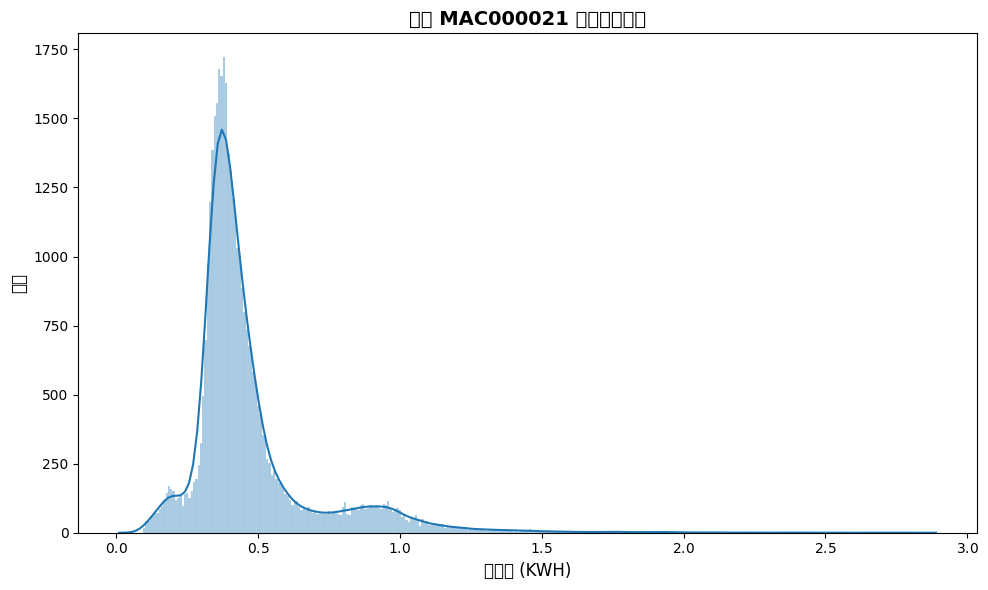

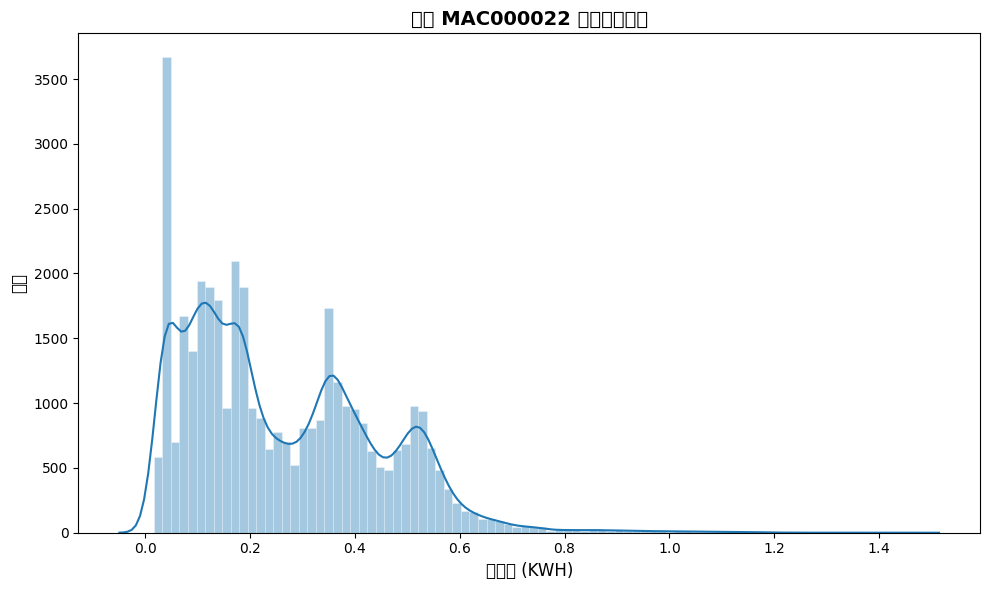

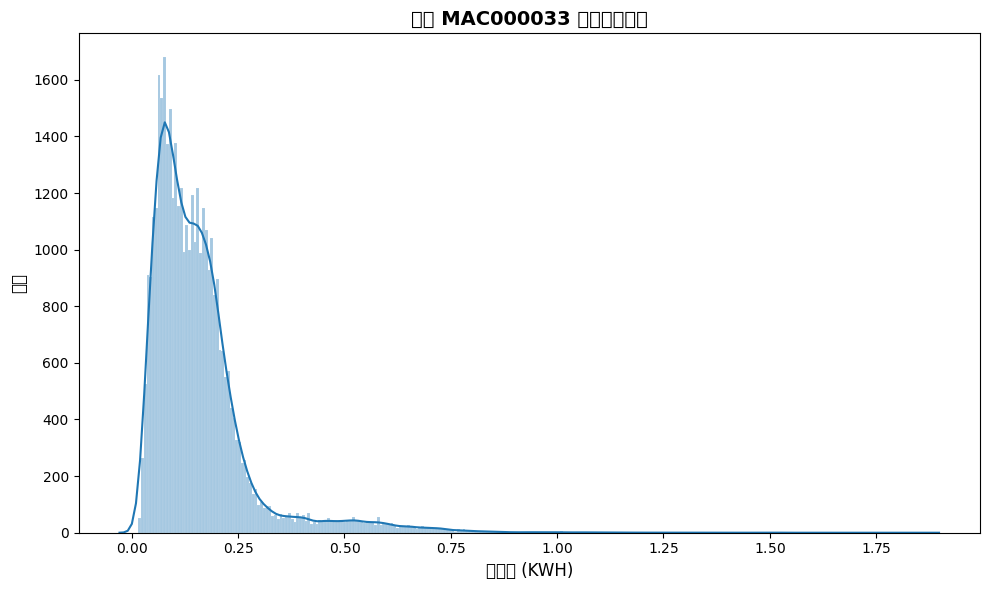

In [19]:
# 选择前5个数据量最多的客户进行分布可视化
top_customers = df_lags_y['customer_id'].value_counts().head(5).index.tolist()
print(f"绘制前5个客户的用电量分布图")

for customer_id in top_customers:
    tmp = df_lags_y.loc[df_lags_y.customer_id == customer_id]
    if len(tmp) > 0:
        distribution_plot(tmp, "kwh", customer_id=customer_id, bins='auto')

### 去除极端异常值后重新查看每个客户的分布

异常值边界: 下界=-0.2325, 上界=0.5475
去除异常值后的数据量: 907,855 (原始: 999,700)


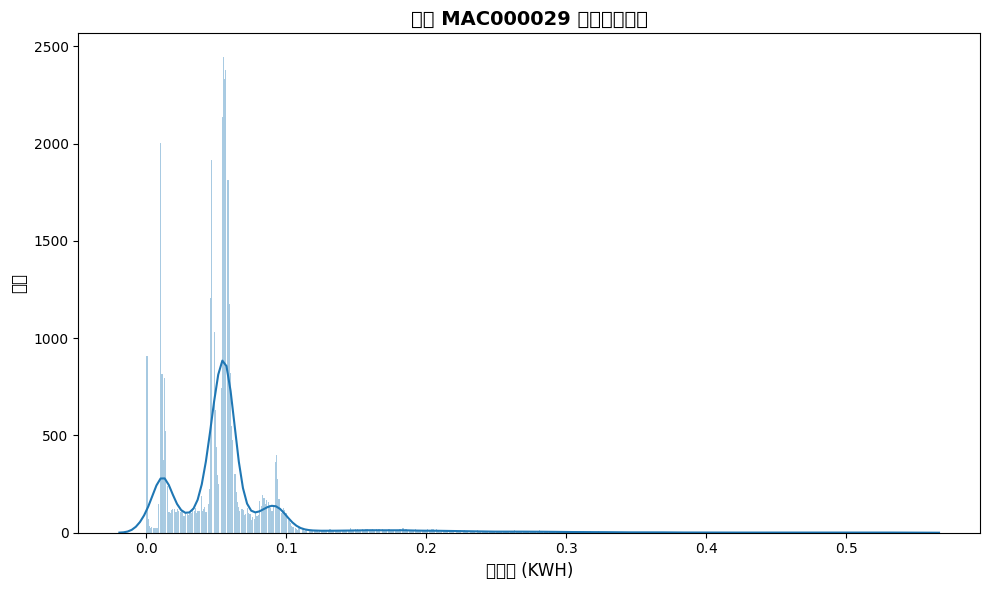

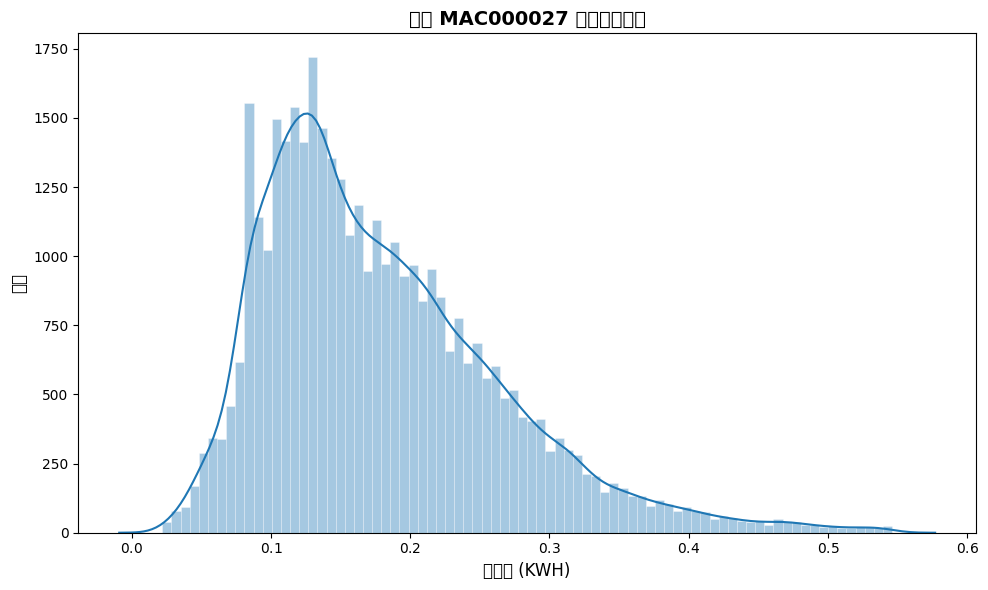

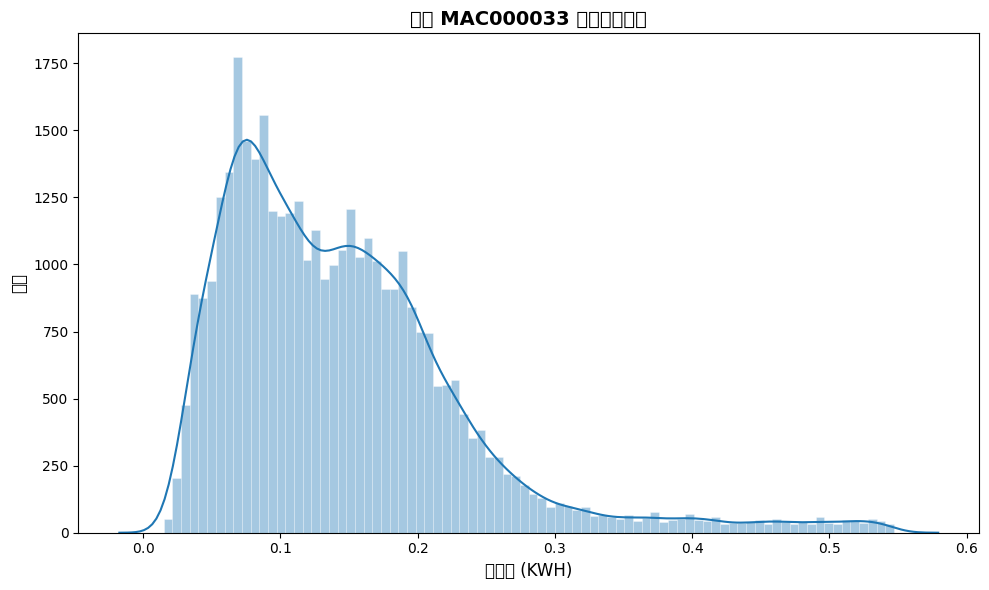

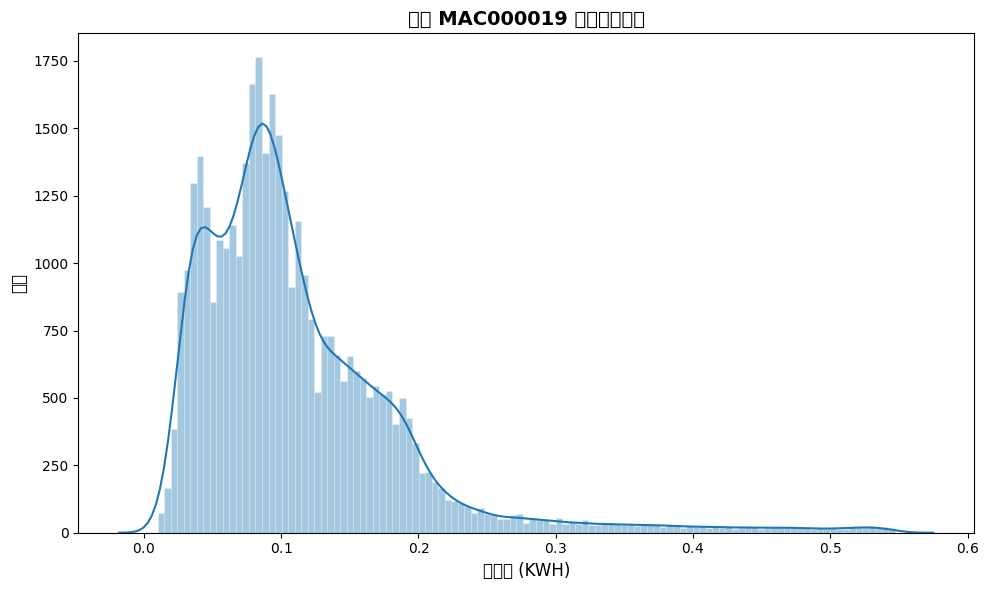

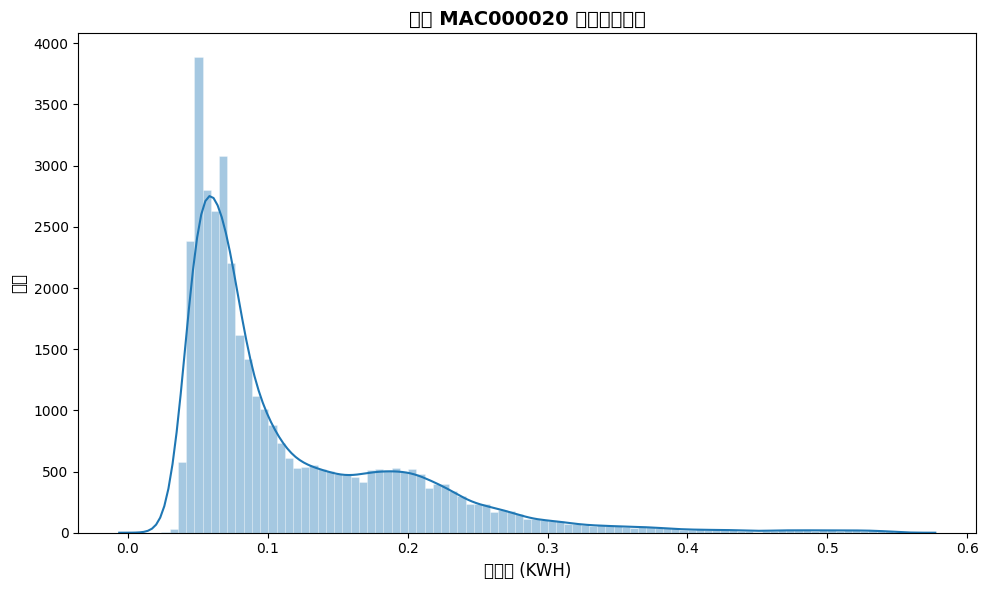

In [20]:
# 使用IQR方法去除极端异常值
tmp_df = copy.deepcopy(df_lags_y)
Q1 = tmp_df['kwh'].quantile(0.25)
Q3 = tmp_df['kwh'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"异常值边界: 下界={lower_bound:.4f}, 上界={upper_bound:.4f}")
tmp_df = tmp_df.loc[(tmp_df.kwh >= lower_bound) & (tmp_df.kwh <= upper_bound)]
print(f"去除异常值后的数据量: {len(tmp_df):,} (原始: {len(df_lags_y):,})")

# 选择前5个客户
top_customers = tmp_df['customer_id'].value_counts().head(5).index.tolist()
for customer_id in top_customers:
    tmp = tmp_df.loc[tmp_df.customer_id == customer_id]
    if len(tmp) > 0:
        distribution_plot(tmp, "kwh", customer_id=customer_id, bins='auto')

### 打印每个客户数据集的统计信息：偏度、峰度等

In [21]:
def get_stats(df, col, customer_id):
    print(f"\tSkewness [{col}]: {df[col].skew():.4f}")
    print(f"\tKurtosis [{col}]: {df[col].kurt():.4f}")
    print(f"\tMean: {df[col].mean():.4f}, Median: {df[col].median():.4f}")
    mode_values = df[col].mode().values
    if len(mode_values) > 0:
        print(f"\tMode: {mode_values[0]:.4f}")
    else:
        print(f"\tMode: N/A")
    print(f"\tStd: {df[col].std():.4f}, Min: {df[col].min():.4f}, Max: {df[col].max():.4f}")

In [23]:
# 选择前10个数据量最多的客户进行统计分析
top_customers = df_lags_y['customer_id'].value_counts().head(20).index.tolist()
print(f"对前10个客户的用电量进行统计分析:\n")

for customer_id in top_customers:
    tmp = df_lags_y.loc[df_lags_y.customer_id == customer_id]
    if len(tmp) > 0:
        print("=" * 60)
        print(f"客户: {customer_id}")
        print(f"数据点数: {len(tmp):,}")
        get_stats(tmp, "kwh", customer_id=customer_id)
        print()

对前10个客户的用电量进行统计分析:

客户: MAC000018
数据点数: 39,072
	Skewness [kwh]: 3.5766
	Kurtosis [kwh]: 19.7766
	Mean: 0.2238, Median: 0.1520
	Mode: 0.1300
	Std: 0.1731, Min: 0.0880, Max: 2.0880

客户: MAC000020
数据点数: 39,069
	Skewness [kwh]: 3.8636
	Kurtosis [kwh]: 20.4083
	Mean: 0.1367, Median: 0.0840
	Mode: 0.0480
	Std: 0.1437, Min: 0.0240, Max: 2.0090

客户: MAC000021
数据点数: 39,069
	Skewness [kwh]: 2.5760
	Kurtosis [kwh]: 9.8120
	Mean: 0.4689, Median: 0.4020
	Mode: 0.3740
	Std: 0.2288, Min: 0.0930, Max: 2.8080

客户: MAC000022
数据点数: 39,062
	Skewness [kwh]: 0.8261
	Kurtosis [kwh]: 0.6245
	Mean: 0.2615, Median: 0.2110
	Mode: 0.0390
	Std: 0.1818, Min: 0.0160, Max: 1.4490

客户: MAC000033
数据点数: 39,061
	Skewness [kwh]: 2.8249
	Kurtosis [kwh]: 12.5410
	Mean: 0.1578, Median: 0.1320
	Mode: 0.0660
	Std: 0.1216, Min: 0.0150, Max: 1.8540

客户: MAC000019
数据点数: 39,061
	Skewness [kwh]: 3.6649
	Kurtosis [kwh]: 17.1501
	Mean: 0.1295, Median: 0.0960
	Mode: 0.0950
	Std: 0.1288, Min: 0.0100, Max: 1.6410

客户: MAC000034
数据点数: 39